In [1]:
from pathlib import Path
import io, tarfile
import h5py
import hdf5plugin  # noqa: F401 — registers Blosc/Bitshuffle/LZ4 used by ESRF
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
DATA_ROOT = Path(r"../data_esrf/")

# Registry of all scans. `main` = primary frame stack (3D, uint16 or float32).
# Optional: `pre` (precomputed float32 preprocessed), `log_tar` (LoG-TIF tar).
# Every folder has segvol.h5 / dataset "segvol" — assumed by default.
DATASETS = {
  "Al":              {"main": "_iris_iris_500_cont.h5",
                      "pre":  "full.h5"},
  "Al_big_grains":   {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
  "Al_deformed_LoG": {"main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5",
                      "log_tar": "A2050_as_annealed_DT_W370_0p12_strain_dct3.tar"},
  "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
  "Cu":              {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
  "IN718_twins":     {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
  "Iron":            {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
  "Iron_deformed":   {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
  "Ti7Al":           {"main": "sam_23_dct4_sam_23_dct.h5"},
}

# === SELECT SCAN ===  change this one line, re-run setup, then run sections below
MATERIAL = "Al"

entry     = DATASETS[MATERIAL]
SCAN_DIR  = DATA_ROOT / MATERIAL
raw_path  = SCAN_DIR / entry["main"]
RAW_KEY   = entry.get("main_key", "instrument/detector_0/data")
PRE_KEY   = entry.get("pre_key",  "image/data")
SEG_KEY   = entry.get("seg_key",  "segvol")

N_HALF          = 10
FRIEDEL_OFFSET  = 1800        # frames = 180° at 0.1°/frame
START           = 1200        # side A start; side B = START + FRIEDEL_OFFSET

def peek_h5(path):
  with h5py.File(path, "r") as f:
      print(f"== {path.name} ==")
      def visitor(name, obj):
          if isinstance(obj, h5py.Dataset):
              print(f"DATASET  {name:40s} shape={obj.shape} dtype={obj.dtype}")
          elif isinstance(obj, h5py.Group):
              print(f"GROUP    {name}")
      f.visititems(visitor)

def load_batch_pair(ds, start=START, n=N_HALF, offset=FRIEDEL_OFFSET):
  """Read n frames at `start` and n frames at `start + offset` (180° around).
  Returns (start_a, batch_a, start_b, batch_b)."""
  a = ds[start : min(ds.shape[0], start + n)]
  sb = start + offset
  b = ds[sb : min(ds.shape[0], sb + n)]
  return start, a, sb, b

def show_montage_pair(batch_a, start_a, batch_b, start_b,
                      cmap="gray", suptitle=None, frame_size=6):
  """Display two batches side-by-side as two columns of full-resolution frames."""
  n = max(len(batch_a), len(batch_b))
  fig, axes = plt.subplots(n, 2, figsize=(2 * frame_size, frame_size * n))
  if n == 1:
      axes = axes.reshape(1, 2)
  for col, (batch, s0, side) in enumerate([
      (batch_a, start_a, "+ω"),
      (batch_b, start_b, "+ω+180°"),
  ]):
      for i in range(n):
          ax = axes[i, col]
          if i < len(batch):
              ax.imshow(batch[i], cmap=cmap)
              ax.set_title(f"{side}   ω={s0 + i}", fontsize=11)
          ax.axis("off")
  if suptitle:
      fig.suptitle(suptitle, fontsize=13)
  fig.tight_layout()

print(f"Available scans: {list(DATASETS)}")
print(f"\nSelected: {MATERIAL}  →  {SCAN_DIR}")
print(f"  main: {entry['main']}")
if "pre" in entry:     print(f"  pre:  {entry['pre']}")
if "log_tar" in entry: print(f"  tar:  {entry['log_tar']}")
print()
print(f"Listing {SCAN_DIR}:")
for p in sorted(SCAN_DIR.glob("*")):
    suffix = "/" if p.is_dir() else ""
    size = "—" if p.is_dir() else f"{p.stat().st_size // 1024**2} MB"
    print(f"  {p.name + suffix:80s}  {size}")


Available scans: ['Al', 'Al_big_grains', 'Al_deformed_LoG', 'Al_small_grains', 'Cu', 'IN718_twins', 'Iron', 'Iron_deformed', 'Ti7Al']

Selected: Al  →  ../data_esrf/Al
  main: _iris_iris_500_cont.h5
  pre:  full.h5

Listing ../data_esrf/Al:
  _dark.h5                                                                          7 MB
  _iris_iris_500_cont.h5                                                            9103 MB
  full.h5                                                                           25665 MB
  segvol.h5                                                                         176 MB


In [ ]:
peek_h5(raw_path)

with h5py.File(raw_path, "r") as f:
  raw = f[RAW_KEY]
  print(f"full shape={raw.shape} dtype={raw.dtype}")
  sa, ba, sb, bb = load_batch_pair(raw)
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb,
                  suptitle=f"{MATERIAL} raw ({raw_path.name}) — Friedel-offset pair around ω={sa}")


Showing 20 Friedel pairs. One figure per pair.
side   frame  partner_frame  label_id  pixels  bbox_yx
left    1200           3000       103    5630  1419:1511, 1642:1730
left    1200           3000        57    3742  1626:1711, 191:284
left    1200           3000        35    1055  227:272, 3:35
left    1200           3000        54     827  443:478, 55:89
left    1200           3000        38     806  135:176, 727:755
left    1200           3000        30     738  1830:1868, 1581:1610
left    1200           3000        29     702  646:676, 1564:1601
left    1200           3000        28     701  2005:2039, 1150:1187
left    1200           3000        30     684  1780:1821, 3:31
left    1200           3000        50     246  405:428, 865:881
left    1200           3000        23     226  1798:1819, 1547:1567
left    1200           3000        24     204  1727:1750, 1345:1362
left    1200           3000        45     147  485:497, 1035:1053
left    1200           3000        24      45 

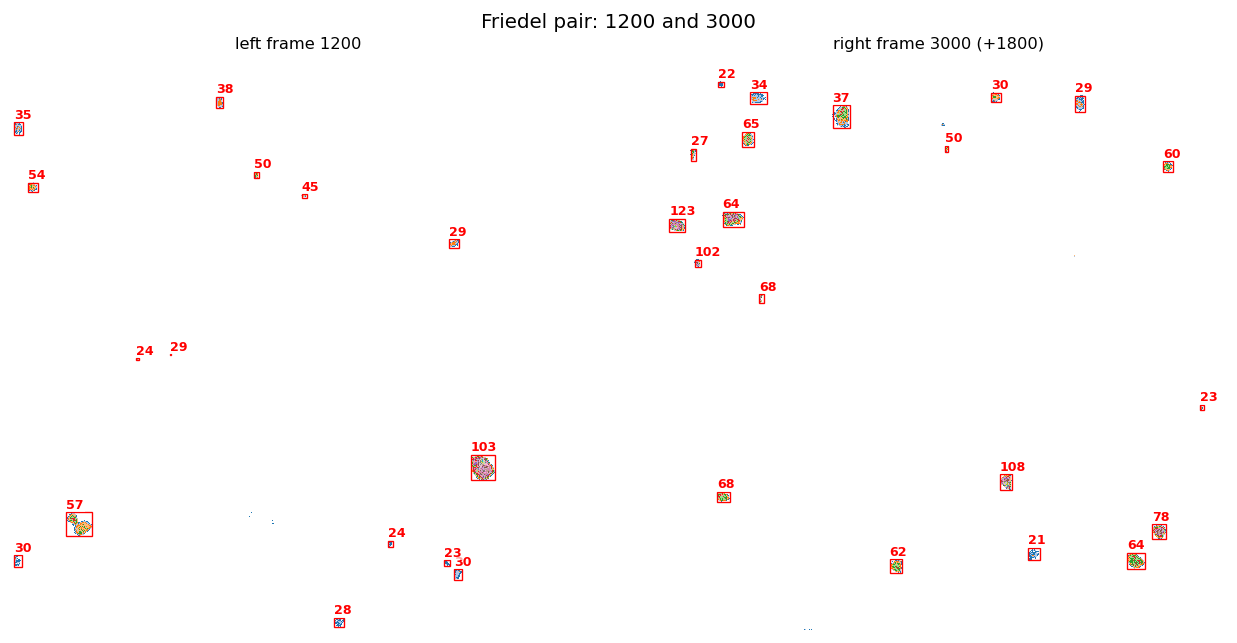

left    1201           3001       269   12630  1274:1405, 1151:1288
left    1201           3001       195    5041  1437:1520, 80:164
left    1201           3001        77    2528  1813:1865, 1484:1556
left    1201           3001        74    2400  1746:1815, 1748:1800
left    1201           3001        24    2097  1637:1706, 184:250
left    1201           3001       116    1903  1792:1852, 982:1031
left    1201           3001        74    1368  570:622, 1243:1280
left    1201           3001        26    1173  649:695, 557:591
left    1201           3001        30     542  218:275, 853:870
left    1201           3001        27     251  583:607, 756:772
left    1201           3001        32     190  1805:1820, 1036:1055
left    1201           3001        22       8  1367:1371, 1156:1160
left    1201           3001        22       3  1635:1638, 201:203
right   3001           1201       128    5573  1384:1478, 106:194
right   3001           1201       172    5114  1298:1380, 1660:1745
righ

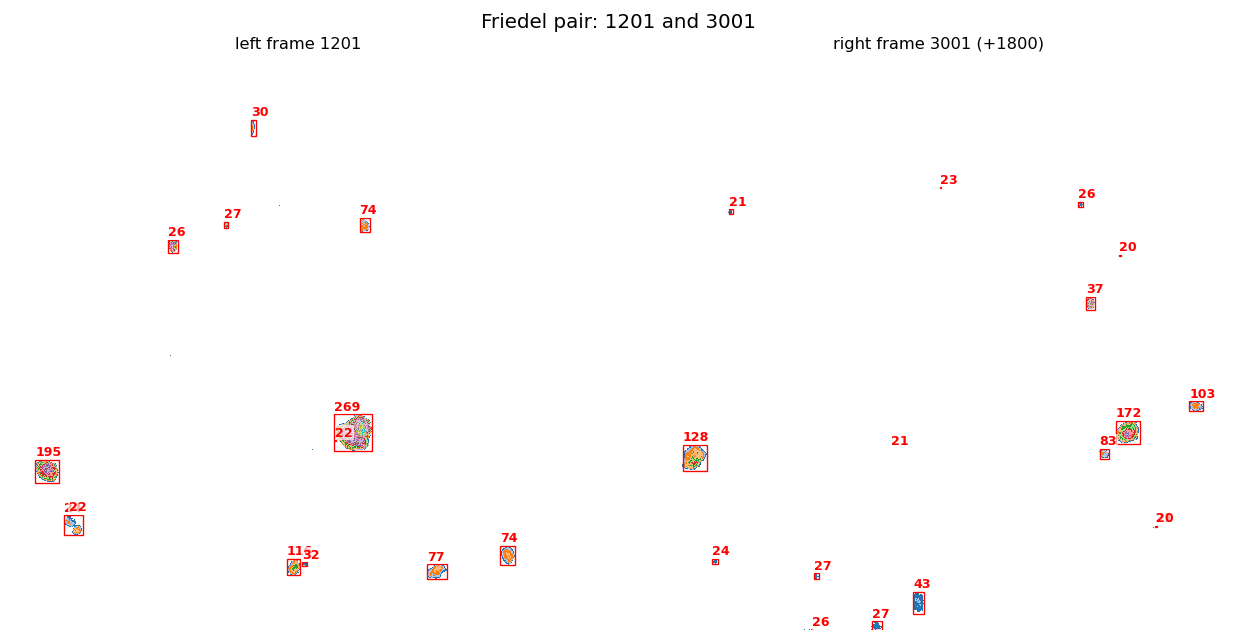

left    1202           3002       189   38045  1437:1685, 1255:1479
left    1202           3002       240   25221  56:307, 738:878
left    1202           3002        21    3669  216:284, 948:1020
left    1202           3002        72    2864  1307:1372, 1803:1884
left    1202           3002        24    2801  1885:1949, 337:402
left    1202           3002       105    1664  494:547, 916:965
left    1202           3002        80    1453  569:624, 1242:1279
left    1202           3002        33    1155  1967:2010, 426:467
left    1202           3002        31     656  463:498, 1505:1542
left    1202           3002        28     488  1985:2017, 1430:1455
left    1202           3002        24     382  1801:1823, 519:549
left    1202           3002        21     354  438:465, 1463:1490
left    1202           3002        22     307  1392:1416, 1056:1084
left    1202           3002        25     124  1525:1547, 1120:1132
left    1202           3002        21      97  1742:1756, 706:725
left  

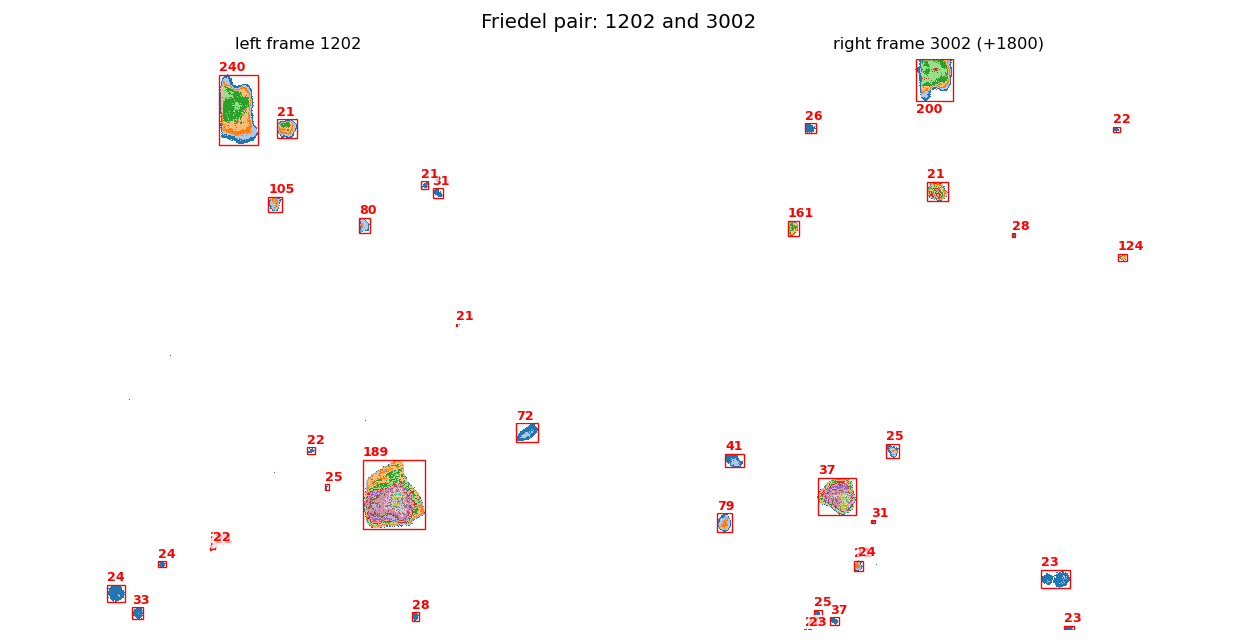

left    1203           3003        84    6192  1647:1724, 1631:1747
left    1203           3003        53    2765  5:84, 1091:1143
left    1203           3003        35    2342  249:306, 1723:1779
left    1203           3003        74    2283  322:377, 13:68
left    1203           3003        37    1645  296:342, 754:811
left    1203           3003        21    1385  487:535, 342:389
left    1203           3003        38    1135  1471:1511, 1547:1593
left    1203           3003       130    1009  1363:1416, 1:26
left    1203           3003        25    1008  1358:1394, 1117:1165
left    1203           3003        23     719  938:965, 1575:1612
left    1203           3003        31     619  1714:1764, 703:731
left    1203           3003        63     346  1205:1227, 413:437
left    1203           3003        24     301  281:307, 846:864
left    1203           3003        24     221  417:440, 72:89
left    1203           3003        21     157  129:156, 1192:1202
left    1203           3

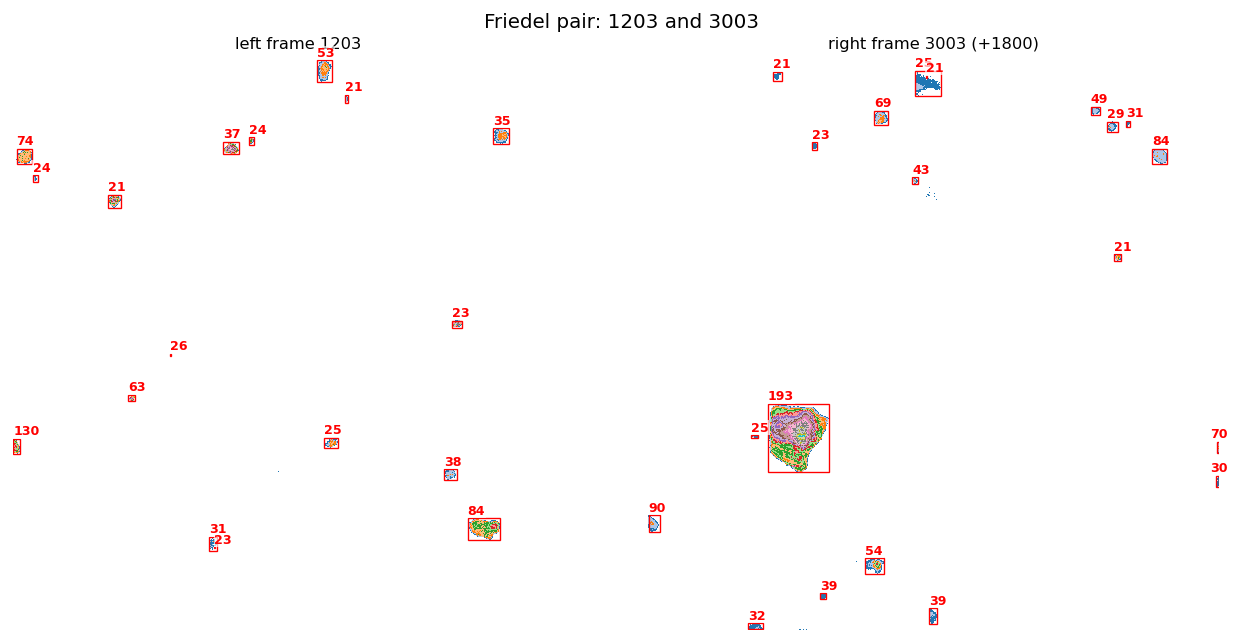

left    1204           3004        31    6869  1243:1358, 3:89
left    1204           3004        32    4557  323:417, 781:850
left    1204           3004        56    3945  1:96, 674:734
left    1204           3004        31    3194  59:124, 1344:1414
left    1204           3004       184    2571  1252:1315, 472:528
left    1204           3004       584    2321  823:882, 1526:1584
left    1204           3004        22    2240  1307:1364, 148:211
left    1204           3004        22    1930  1814:1870, 469:521
left    1204           3004        39    1623  30:72, 968:1019
left    1204           3004        32    1175  631:670, 698:740
left    1204           3004        83    1006  1530:1567, 753:790
left    1204           3004        78     978  1358:1394, 1627:1666
left    1204           3004        21     904  192:242, 225:248
left    1204           3004        58     761  1346:1381, 1146:1178
left    1204           3004        29     611  1718:1757, 754:779
left    1204           3

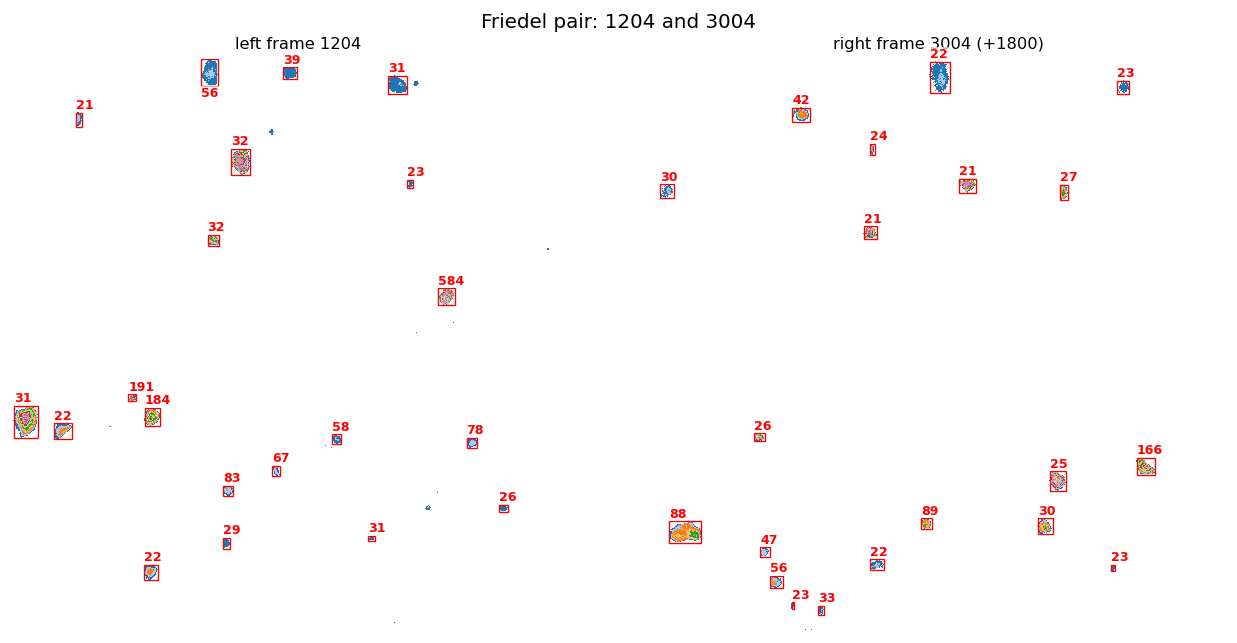

left    1205           3005        33    4558  1255:1367, 1:54
left    1205           3005       177    3601  1598:1678, 1681:1744
left    1205           3005       337    3392  353:427, 1113:1183
left    1205           3005        71    1552  1:43, 1449:1501
left    1205           3005        27    1455  451:493, 277:334
left    1205           3005       160    1354  1362:1412, 1317:1357
left    1205           3005        54    1350  1211:1251, 418:465
left    1205           3005        71    1345  1703:1750, 325:370
left    1205           3005        38    1278  2012:2048, 1357:1404
left    1205           3005        40     842  643:679, 1901:1937
left    1205           3005        72     813  1603:1650, 740:768
left    1205           3005        21     792  1526:1563, 1511:1543
left    1205           3005        26     791  1089:1136, 1463:1488
left    1205           3005        24     735  968:999, 1427:1461
left    1205           3005        34     644  309:344, 1572:1600
left    

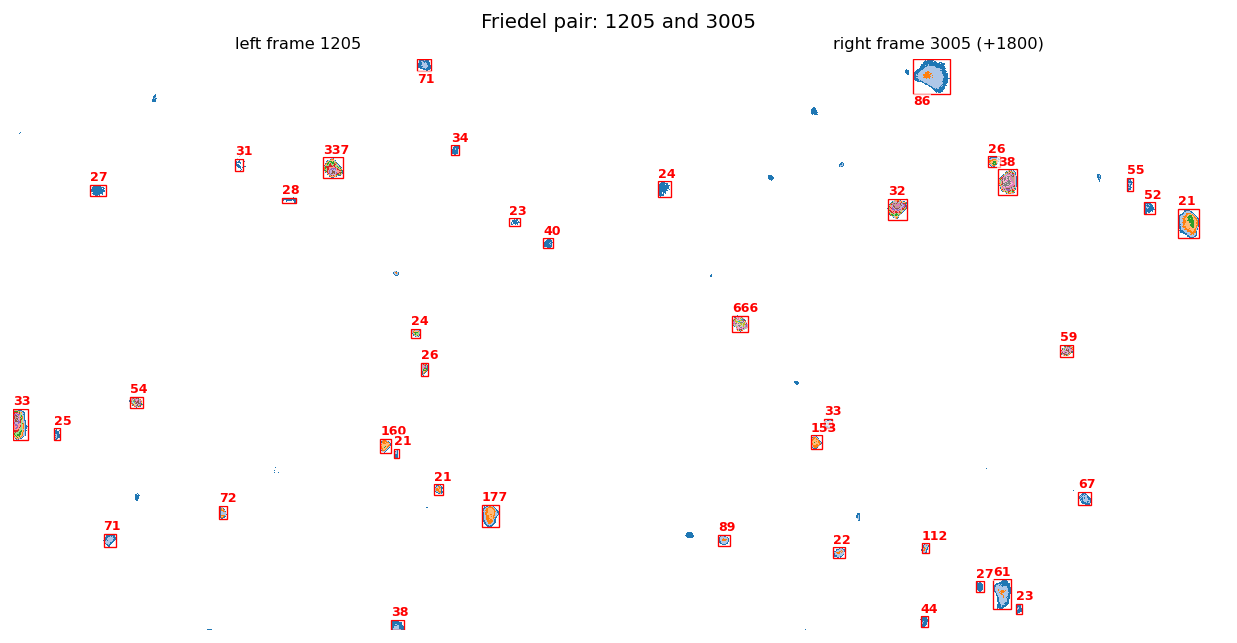

left    1206           3006        28    3170  1303:1357, 530:609
left    1206           3006       120    2651  47:112, 1173:1234
left    1206           3006       146    2383  615:681, 516:566
left    1206           3006        45    2304  44:103, 1492:1551
left    1206           3006        69    1717  1846:1897, 453:501
left    1206           3006        29    1461  2:52, 404:453
left    1206           3006        60    1441  1742:1786, 310:359
left    1206           3006        88    1085  1778:1814, 381:424
left    1206           3006       182    1043  1493:1531, 743:780
left    1206           3006        67    1015  556:597, 845:880
left    1206           3006        33     718  645:678, 1901:1933
left    1206           3006        25     715  1:31, 1455:1492
left    1206           3006        29     701  420:451, 1422:1455
left    1206           3006        24     647  649:685, 1371:1397
left    1206           3006        86     643  510:544, 211:241
left    1206           300

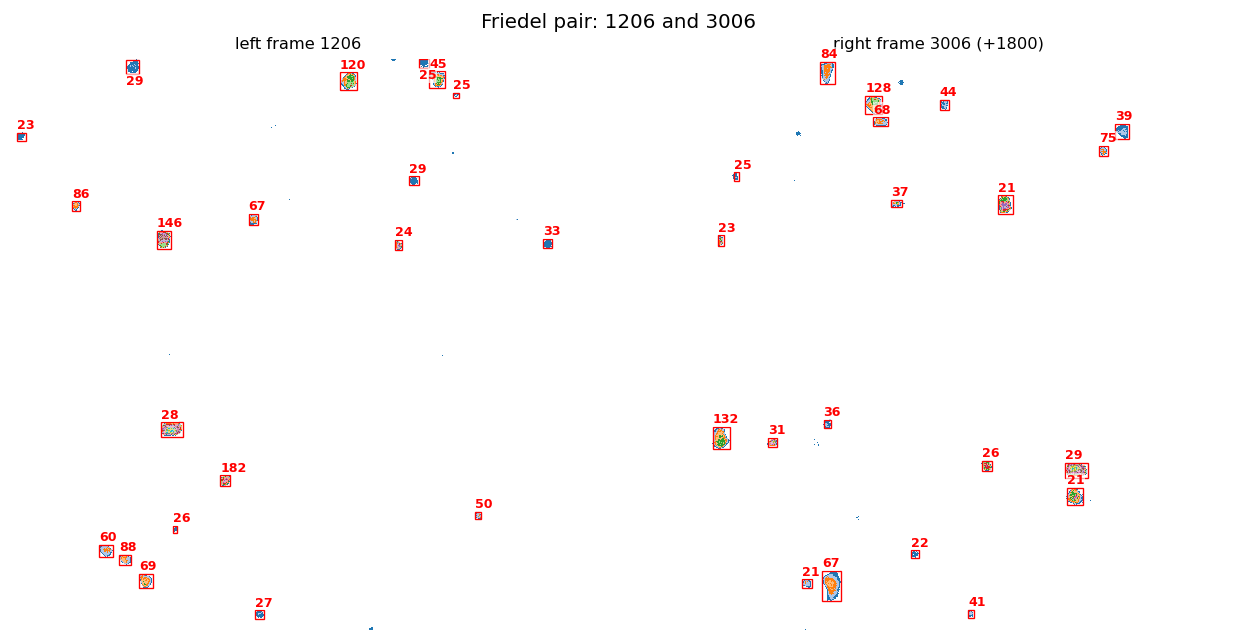

left    1207           3007        30    4767  1952:2047, 419:509
left    1207           3007        36    4609  633:724, 387:460
left    1207           3007        22    3057  1227:1299, 411:467
left    1207           3007        27    2540  1300:1380, 1470:1517
left    1207           3007       133    2253  225:283, 895:949
left    1207           3007       657    1636  858:910, 412:451
left    1207           3007        56    1525  375:428, 1844:1884
left    1207           3007        90    1221  1731:1769, 413:458
left    1207           3007        55    1000  245:290, 288:331
left    1207           3007        26     991  540:591, 1368:1395
left    1207           3007        30     834  1945:1982, 1540:1576
left    1207           3007        23     767  1742:1772, 1064:1097
left    1207           3007        29     715  1994:2029, 1376:1411
left    1207           3007        36     714  1471:1507, 264:295
left    1207           3007        61     677  1387:1419, 191:221
left    12

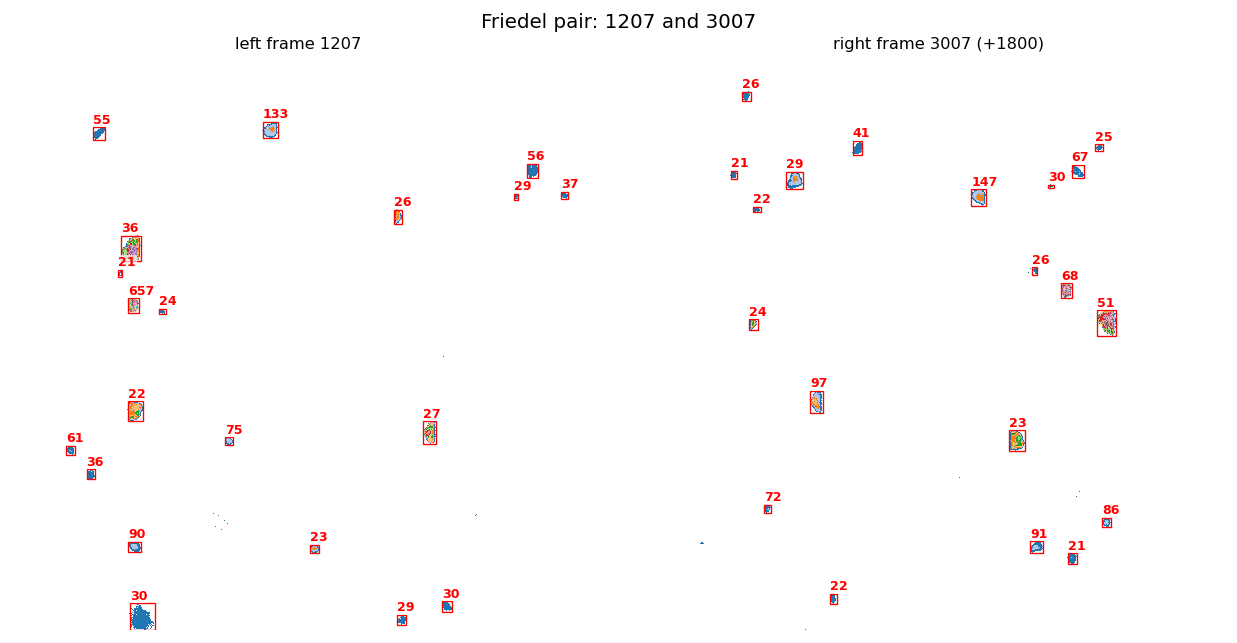

left    1208           3008       138   25695  1864:2047, 307:518
left    1208           3008       172    5268  1621:1705, 702:790
left    1208           3008        67    2742  1670:1781, 1315:1356
left    1208           3008       118    2185  272:332, 963:1015
left    1208           3008        21    1836  731:790, 349:394
left    1208           3008        25    1771  995:1051, 1905:1946
left    1208           3008        39    1764  1799:1851, 291:350
left    1208           3008        57    1603  1634:1678, 469:522
left    1208           3008        32    1478  60:104, 1459:1506
left    1208           3008       144    1472  1050:1102, 1843:1886
left    1208           3008        86    1401  1038:1074, 343:397
left    1208           3008        24    1244  1410:1454, 1519:1560
left    1208           3008        34    1219  149:191, 307:355
left    1208           3008        40    1105  1920:1969, 1653:1688
left    1208           3008        55     879  151:202, 511:536
left    1

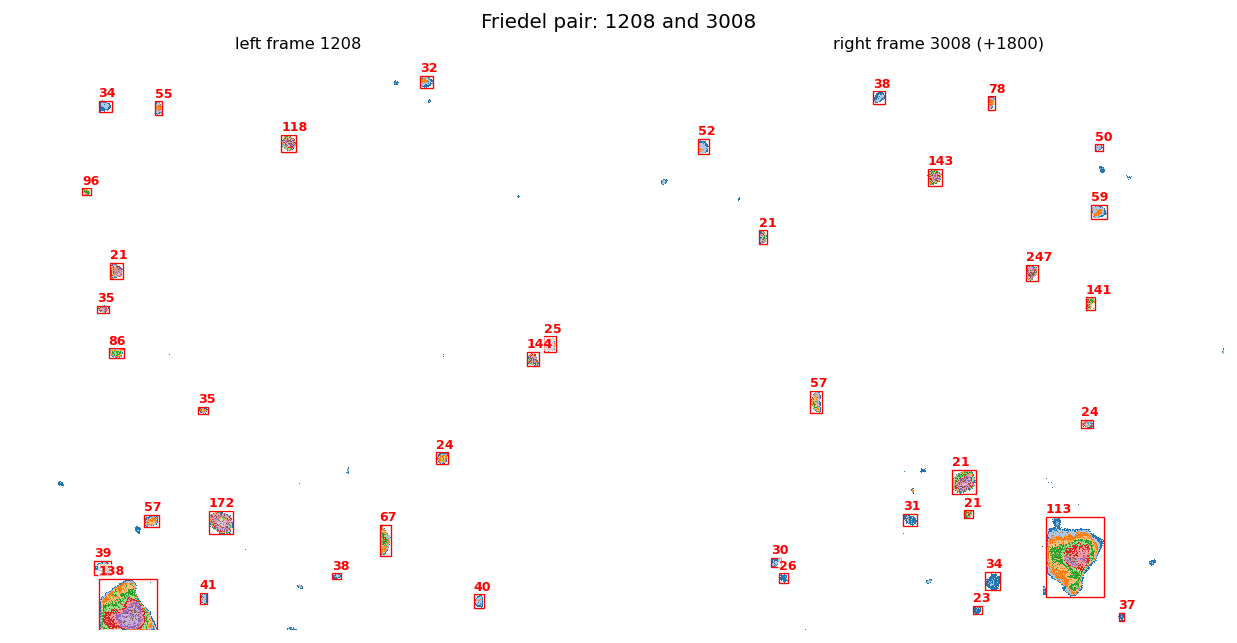

left    1209           3009        74    2562  1828:1886, 575:640
left    1209           3009        65    2375  1563:1618, 1759:1822
left    1209           3009       159    2311  1215:1275, 652:707
left    1209           3009        86    2184  815:871, 489:536
left    1209           3009        88    1190  1487:1531, 1004:1058
left    1209           3009        21    1027  1500:1551, 1321:1354
left    1209           3009        45     991  165:210, 96:131
left    1209           3009        54     962  1942:1981, 973:1010
left    1209           3009        48     817  1893:1931, 521:553
left    1209           3009        41     704  289:325, 352:379
left    1209           3009        25     700  163:198, 312:357
left    1209           3009        22     685  727:789, 656:674
left    1209           3009        22     641  1694:1759, 607:627
left    1209           3009        24     618  1732:1778, 820:842
left    1209           3009        25     472  1864:1910, 493:513
left    1209  

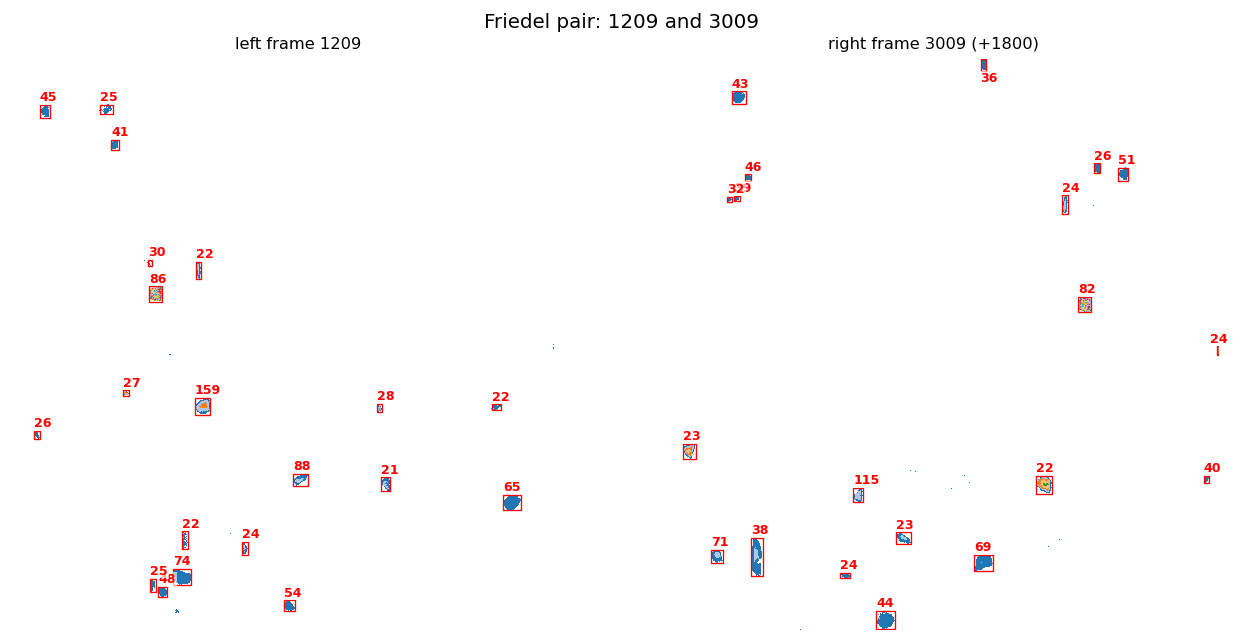

left    1210           3010        89    2149  369:419, 1057:1114
left    1210           3010       149    2017  172:226, 851:905
left    1210           3010       123    1746  387:438, 961:1008
left    1210           3010        58    1171  396:444, 444:479
left    1210           3010        48    1101  1644:1689, 284:321
left    1210           3010       187    1090  707:748, 464:502
left    1210           3010        52     794  87:127, 1074:1101
left    1210           3010        24     720  1615:1660, 620:642
left    1210           3010        25     707  1227:1263, 1705:1754
left    1210           3010        38     617  118:146, 941:980
left    1210           3010        22     438  1699:1758, 607:625
left    1210           3010        27     432  1429:1454, 1756:1783
left    1210           3010        29     394  329:352, 996:1023
left    1210           3010        27     355  1062:1092, 1917:1940
left    1210           3010        25     326  1662:1691, 743:758
left    1210   

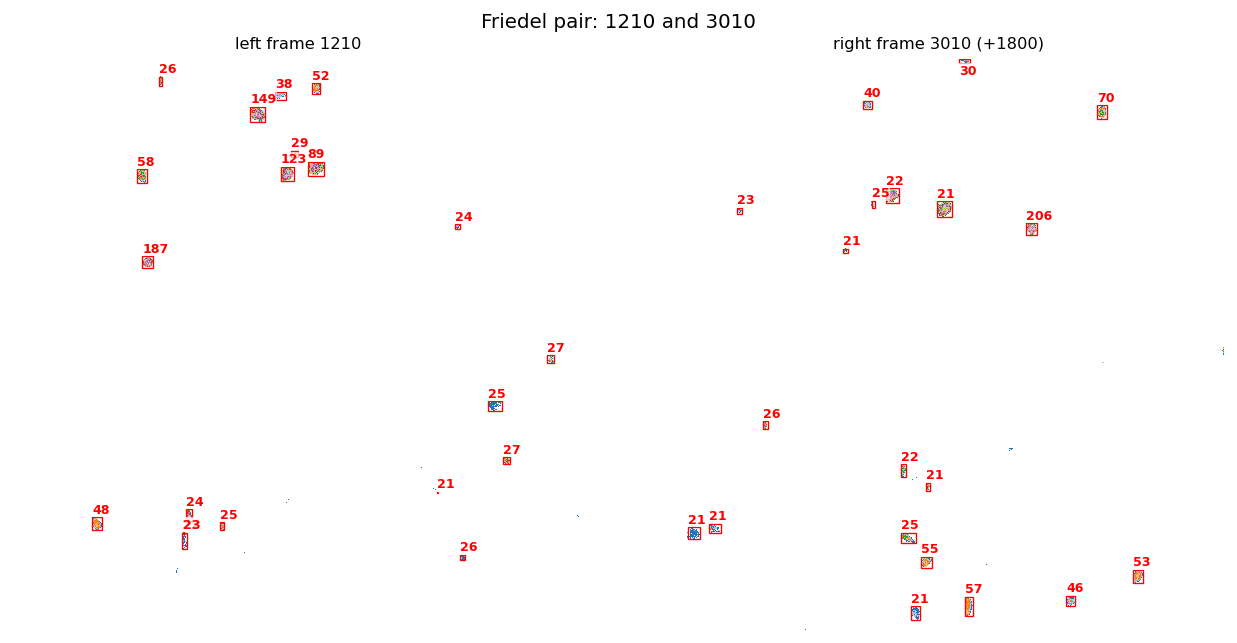

left    1211           3011       118   48049  80:461, 890:1103
left    1211           3011        42    5276  515:604, 395:480
left    1211           3011       116    4768  425:524, 320:390
left    1211           3011       132    3311  195:257, 1591:1662
left    1211           3011       143    3087  1521:1608, 689:738
left    1211           3011        37    2396  1770:1829, 83:138
left    1211           3011       133    2277  1647:1698, 563:624
left    1211           3011        24    2042  1520:1573, 1475:1529
left    1211           3011        68    1958  1601:1654, 1982:2035
left    1211           3011        22    1863  1556:1616, 957:1004
left    1211           3011        34    1654  739:782, 479:534
left    1211           3011        30    1302  1772:1826, 490:528
left    1211           3011        24    1163  433:474, 775:816
left    1211           3011        53    1130  1013:1054, 1471:1513
left    1211           3011        25    1039  1789:1833, 783:819
left    1211  

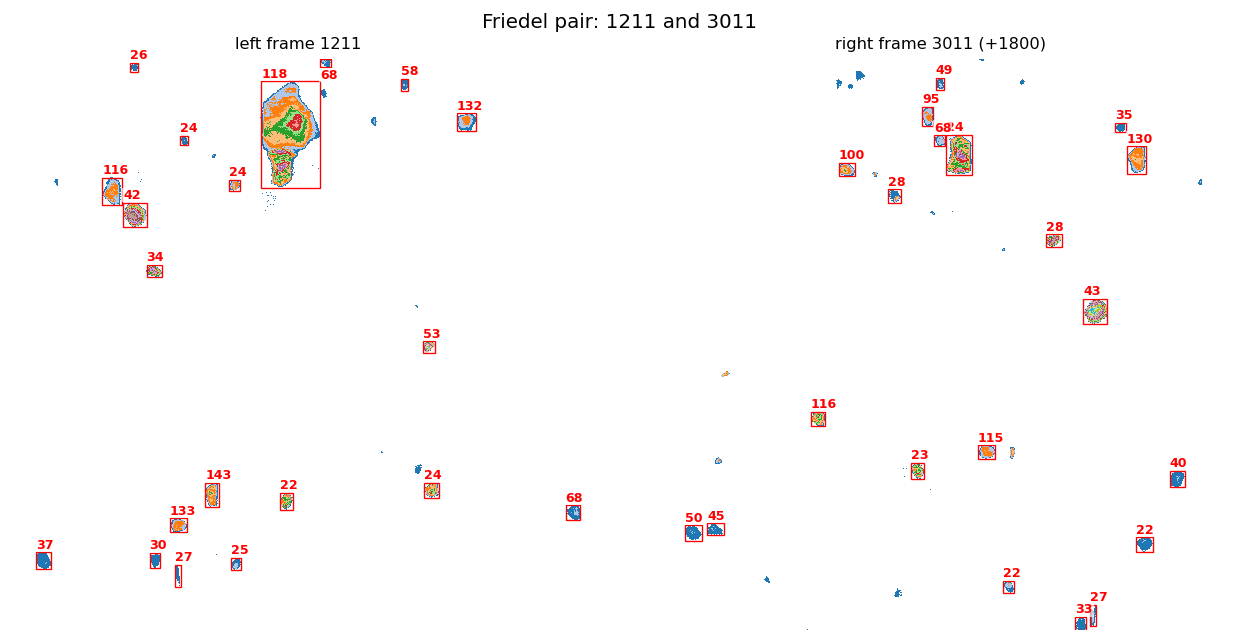

left    1212           3012        23    3703  471:558, 877:947
left    1212           3012       117    2020  1604:1659, 1057:1111
left    1212           3012       191    1696  1032:1085, 1938:1984
left    1212           3012        36    1690  103:158, 581:626
left    1212           3012        34    1687  852:899, 1433:1483
left    1212           3012        90    1529  1770:1816, 1024:1072
left    1212           3012        90    1278  367:411, 1571:1609
left    1212           3012        97    1087  136:182, 994:1027
left    1212           3012        34     974  472:511, 781:822
left    1212           3012        38     887  1748:1784, 230:272
left    1212           3012        22     818  1875:1915, 1278:1314
left    1212           3012       171     795  636:665, 370:410
left    1212           3012        47     786  1941:1975, 842:878
left    1212           3012        29     523  1679:1711, 1238:1264
left    1212           3012        21     504  176:203, 470:496
left    121

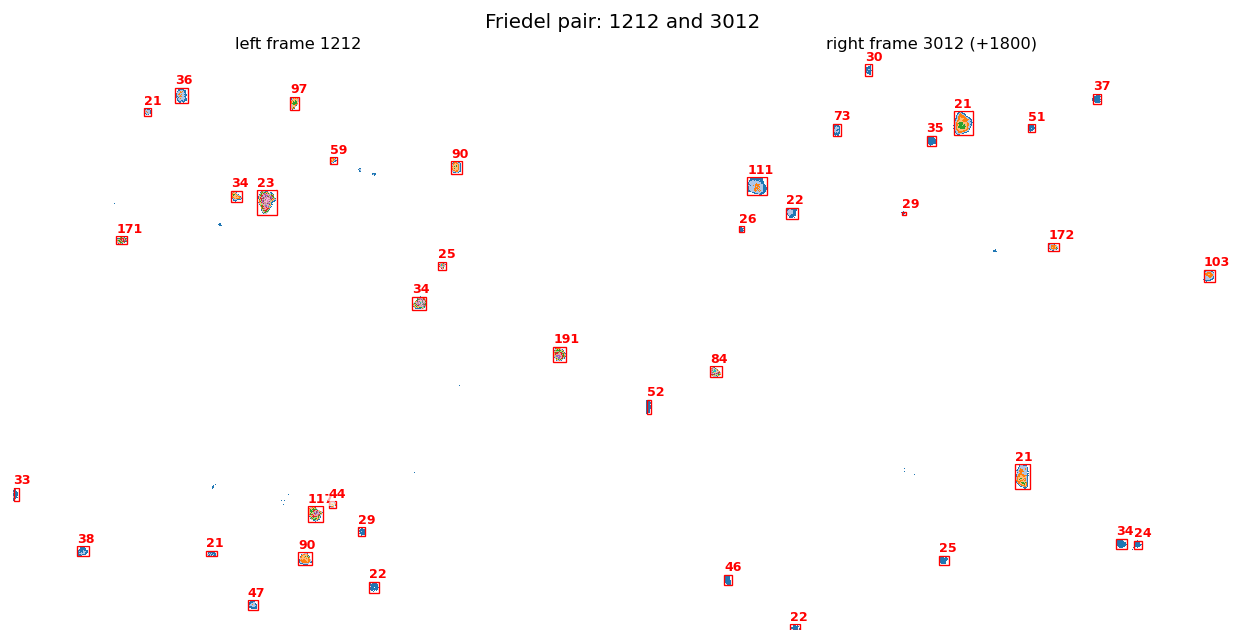

left    1213           3013       394   10592  595:726, 1341:1451
left    1213           3013        21    2248  1646:1706, 1089:1144
left    1213           3013        62    1956  14:71, 764:812
left    1213           3013        43    1670  359:408, 1927:1978
left    1213           3013        43    1590  285:323, 362:423
left    1213           3013        24    1495  478:529, 781:826
left    1213           3013        94    1461  162:207, 561:604
left    1213           3013        81    1324  317:363, 530:576
left    1213           3013        29    1302  176:222, 1244:1296
left    1213           3013        54     921  175:215, 364:400
left    1213           3013        21     874  410:446, 644:678
left    1213           3013        52     819  1618:1662, 221:246
left    1213           3013        31     739  1361:1395, 1213:1245
left    1213           3013        24     720  1333:1377, 460:483
left    1213           3013        36     659  1756:1785, 1570:1604
left    1213        

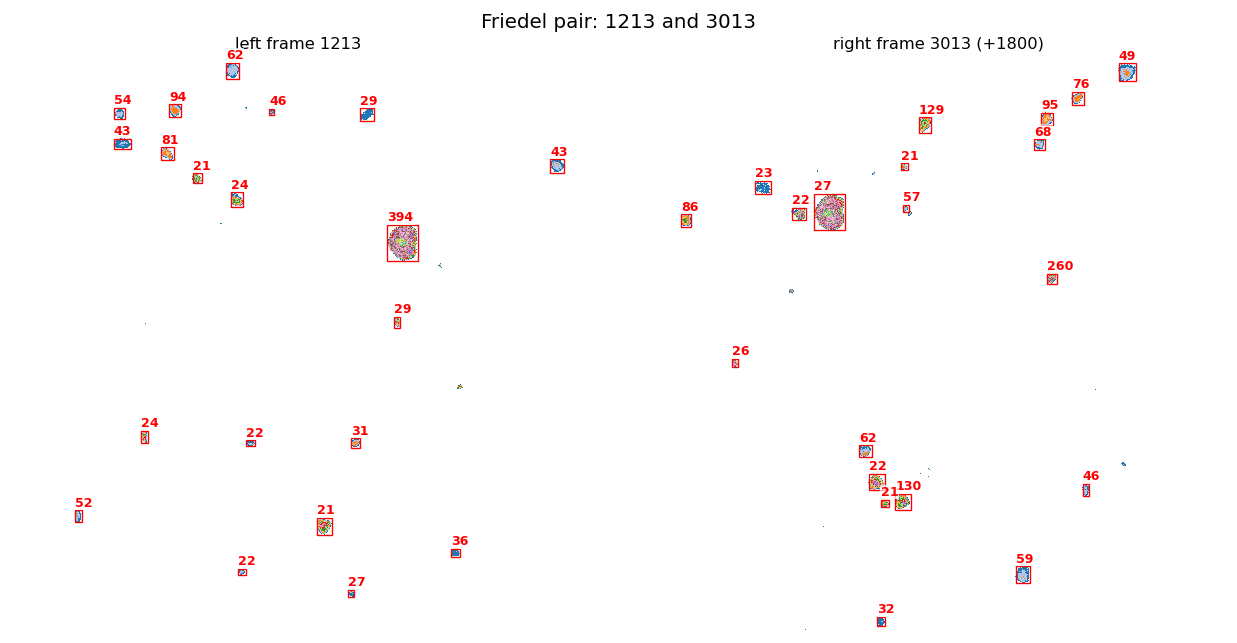

left    1214           3014       144    4292  1705:1789, 744:823
left    1214           3014        50    3805  1891:1957, 974:1051
left    1214           3014        77    3297  317:382, 279:342
left    1214           3014        85    2587  1857:1927, 664:717
left    1214           3014        21    1350  1488:1539, 1806:1850
left    1214           3014        21    1048  578:639, 1126:1153
left    1214           3014       191    1027  497:537, 540:575
left    1214           3014        59     947  621:653, 86:126
left    1214           3014        29     868  925:962, 1358:1388
left    1214           3014        25     825  1770:1803, 1293:1340
left    1214           3014        41     588  1628:1657, 276:304
left    1214           3014        25     496  271:305, 111:136
left    1214           3014        23     454  206:240, 1134:1155
left    1214           3014        26     442  957:990, 1460:1482
left    1214           3014        31     439  350:382, 1790:1811
left    1214  

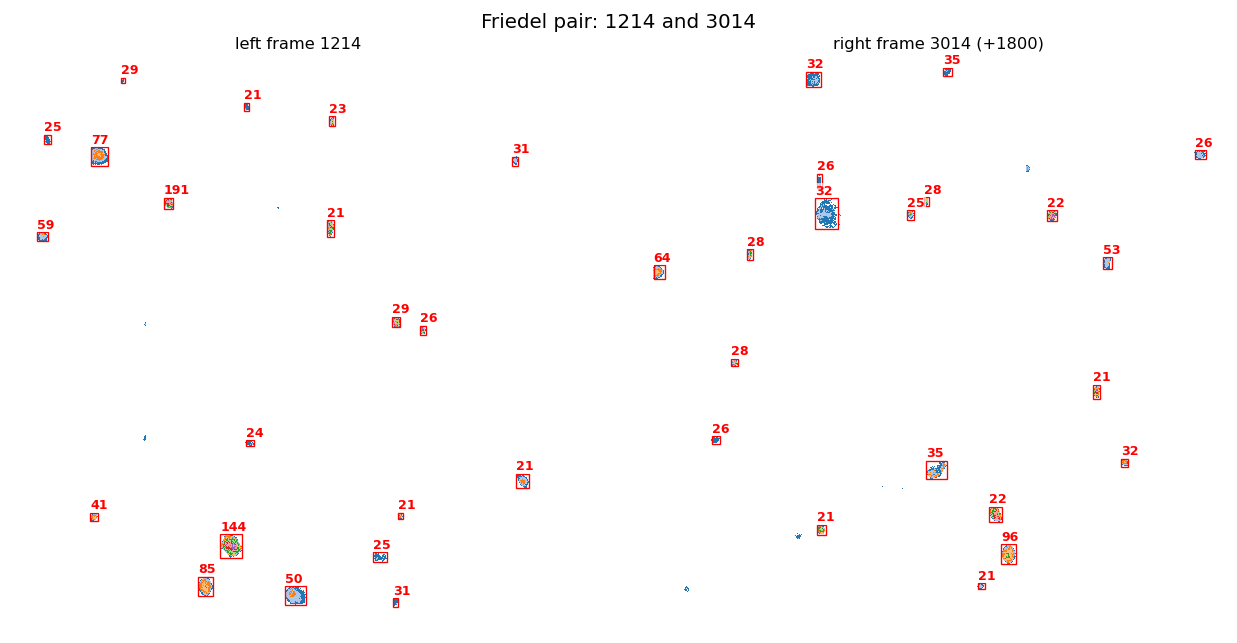

left    1215           3015       112    6520  212:309, 1156:1243
left    1215           3015        88    2486  1768:1820, 192:265
left    1215           3015       672    2036  1091:1139, 1595:1654
left    1215           3015       101    1960  1851:1910, 1572:1617
left    1215           3015       116    1893  256:308, 201:254
left    1215           3015        31    1141  1711:1748, 1840:1891
left    1215           3015        52    1026  619:652, 1823:1868
left    1215           3015        21     744  1361:1401, 1092:1142
left    1215           3015        92     699  1493:1525, 840:874
left    1215           3015        22     532  1645:1681, 1739:1760
left    1215           3015        33     304  222:244, 886:905
left    1215           3015        24     286  1530:1563, 952:966
left    1215           3015        37     215  961:983, 1464:1480
left    1215           3015        21     111  147:159, 975:990
left    1215           3015        21     109  583:599, 792:804
left    

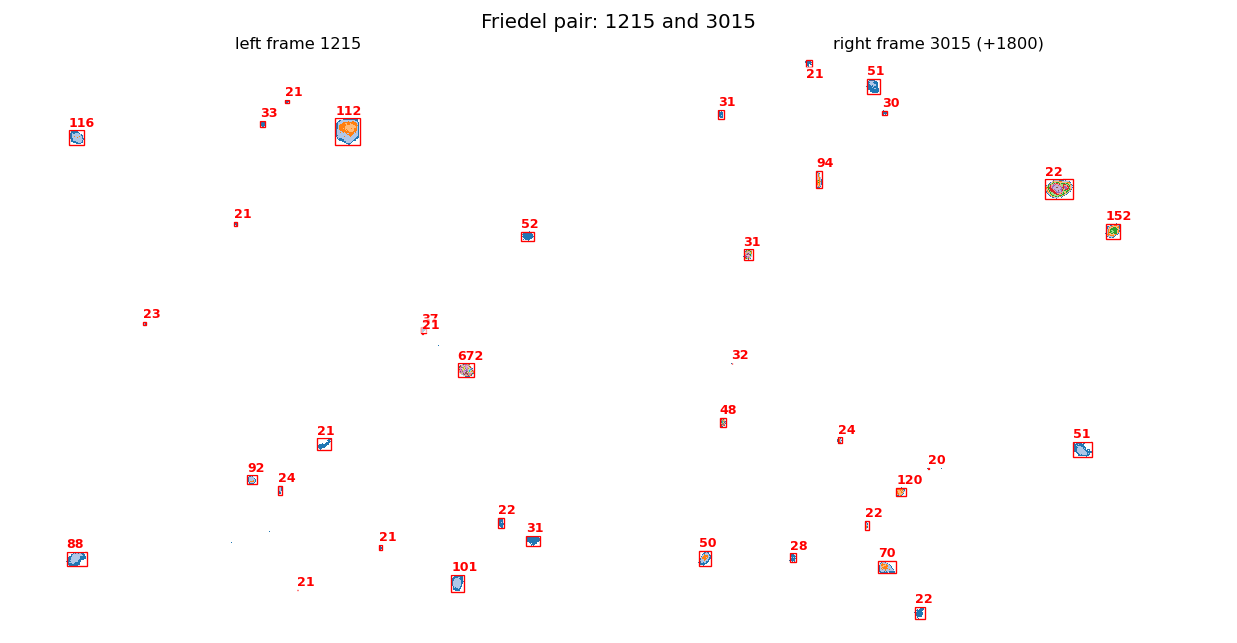

left    1216           3016        42    3764  1810:1886, 316:405
left    1216           3016        24    2670  1451:1519, 971:1035
left    1216           3016        22    1936  1787:1844, 683:734
left    1216           3016        21    1329  1275:1336, 716:750
left    1216           3016        48    1272  506:547, 1585:1631
left    1216           3016        22    1266  1669:1714, 913:956
left    1216           3016       134    1028  317:350, 1012:1058
left    1216           3016        35     774  203:243, 387:417
left    1216           3016        83     723  1466:1503, 1993:2022
left    1216           3016        24     712  1923:1990, 1186:1204
left    1216           3016        23     633  1969:2003, 1400:1432
left    1216           3016        40     565  614:648, 328:350
left    1216           3016        31     370  6:40, 1710:1730
left    1216           3016       122     300  1403:1423, 1307:1326
left    1216           3016        23     273  1858:1884, 455:475
left    

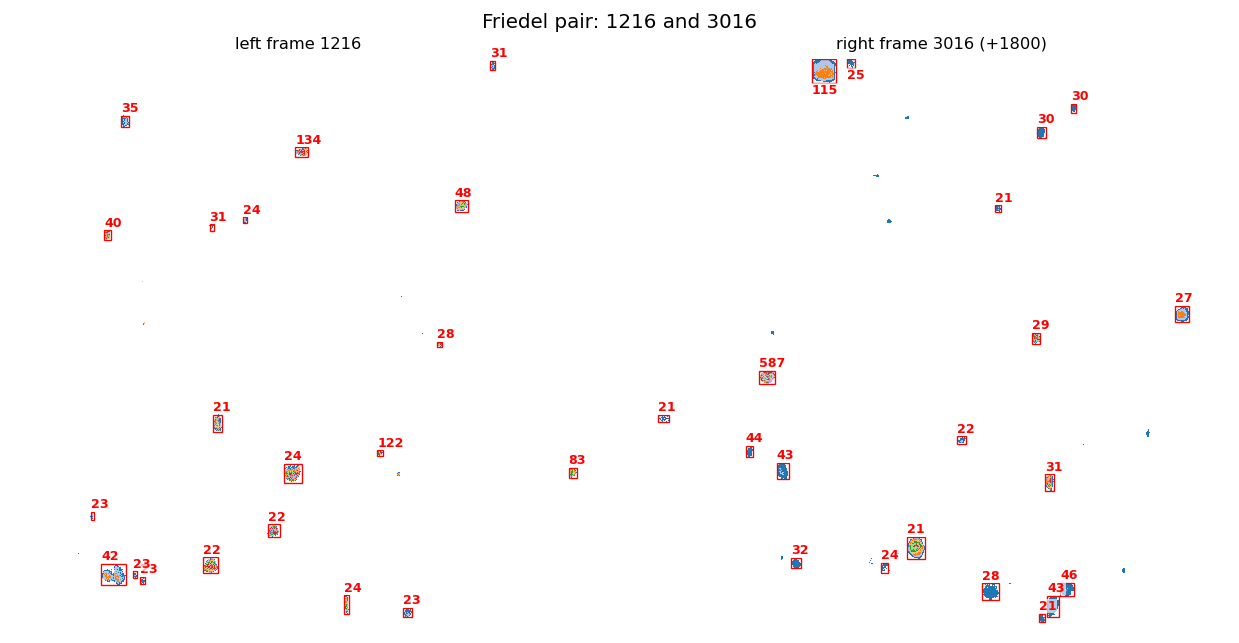

left    1217           3017        40   26294  569:819, 330:478
left    1217           3017        81    4750  107:192, 495:576
left    1217           3017        52    3587  1212:1285, 1880:1945
left    1217           3017        29    2632  416:465, 1368:1433
left    1217           3017        25    2199  506:568, 854:903
left    1217           3017        21    2158  1782:1845, 917:965
left    1217           3017        63    1989  452:509, 175:224
left    1217           3017        51    1569  1741:1796, 1040:1080
left    1217           3017        67    1384  166:209, 1663:1710
left    1217           3017        34     774  366:405, 574:601
left    1217           3017        84     585  1312:1347, 2027:2048
left    1217           3017        21     564  1104:1147, 752:776
left    1217           3017        42     538  806:831, 1588:1617
left    1217           3017        22     457  566:598, 814:837
left    1217           3017        30     383  1744:1770, 602:630
left    1217    

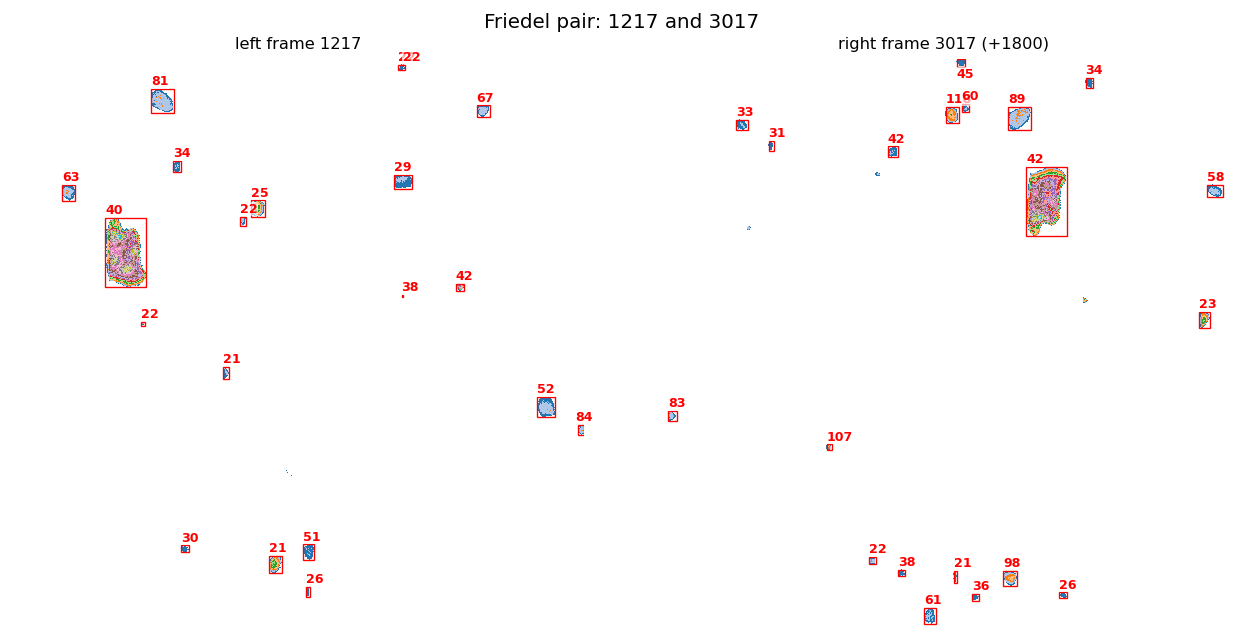

left    1218           3018        40    3769  1607:1685, 1389:1461
left    1218           3018        28    1957  1235:1292, 610:658
left    1218           3018       173    1387  1376:1421, 587:630
left    1218           3018        53    1275  9:58, 1371:1410
left    1218           3018        23    1048  1007:1051, 1633:1668
left    1218           3018        62     950  802:847, 1:31
left    1218           3018        42     861  1870:1910, 1481:1513
left    1218           3018        60     802  99:128, 671:713
left    1218           3018        63     642  598:630, 1157:1188
left    1218           3018        22     553  332:372, 409:433
left    1218           3018        28     436  421:450, 1172:1196
left    1218           3018        46     382  551:575, 1793:1816
left    1218           3018        27     295  72:95, 662:680
left    1218           3018        23      93  180:196, 1063:1072
left    1218           3018        27      74  288:304, 235:244
left    1218           

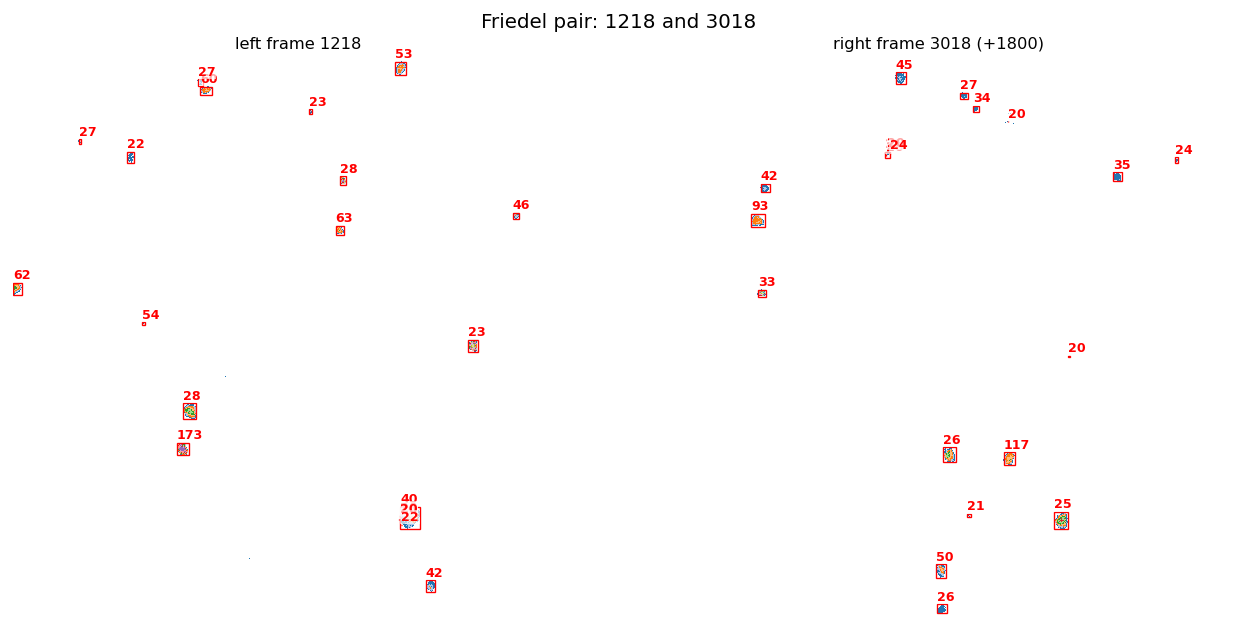

left    1219           3019       143    5560  83:179, 1098:1184
left    1219           3019        53    3810  1610:1686, 1385:1458
left    1219           3019        43    2863  577:645, 1484:1546
left    1219           3019       117    2051  224:294, 394:438
left    1219           3019       140    1702  487:534, 453:500
left    1219           3019       113    1429  1308:1360, 1861:1898
left    1219           3019        26    1335  515:560, 89:132
left    1219           3019        22    1005  795:839, 444:476
left    1219           3019        24     926  1642:1691, 830:856
left    1219           3019        61     907  1495:1531, 1830:1868
left    1219           3019        50     645  339:370, 1073:1104
left    1219           3019        35     569  1864:1908, 736:755
left    1219           3019        50     547  1669:1696, 314:343
left    1219           3019        32     362  1769:1793, 832:856
left    1219           3019        26     344  1790:1814, 385:408
left    1219  

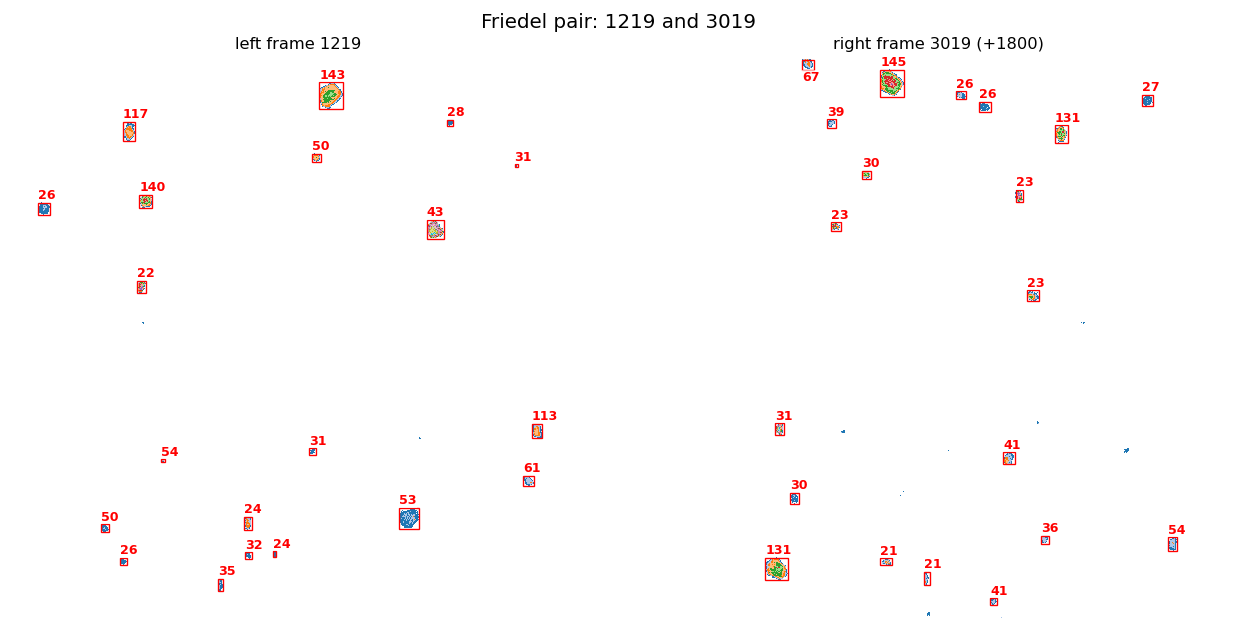

In [4]:
# Show 20 Friedel frame pairs with per-spot bounding boxes.
# Each output figure is one pair: left frame i, right frame i + 1800.
from pathlib import Path
from collections import deque
import h5py
import hdf5plugin  # needed if the file uses ESRF/HDF5 compression plugins
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

seg_path = Path("data/segvol.h5")
start_frame = START
n_pairs_to_show = 20
friedel_offset = FRIEDEL_OFFSET
max_boxes_per_frame = 20
min_pixels = 3
box_linewidth = 0.75
label_fontsize = 7
mirror_right = False  # set True if you want the +1800 frame displayed as np.fliplr(...)


def connected_spot_boxes(seg_frame, max_boxes=max_boxes_per_frame, min_pixels=min_pixels):
    """Find connected visible spots and keep the actual segvol label ID for each spot."""
    coords = set(map(tuple, np.argwhere(seg_frame > 0)))
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    boxes = []

    while coords:
        start = coords.pop()
        queue = deque([start])
        pixels = [start]

        while queue:
            y, x = queue.popleft()
            for dy, dx in neighbors:
                nxt = (y + dy, x + dx)
                if nxt in coords:
                    coords.remove(nxt)
                    queue.append(nxt)
                    pixels.append(nxt)

        if len(pixels) < min_pixels:
            continue

        pixels = np.array(pixels, dtype=np.int32)
        y = pixels[:, 0]
        x = pixels[:, 1]
        label_values, label_counts = np.unique(seg_frame[y, x], return_counts=True)
        label_id = int(label_values[np.argmax(label_counts)])

        boxes.append({
            "label_id": label_id,
            "pixels": int(len(pixels)),
            "y0": int(y.min()),
            "y1": int(y.max() + 1),
            "x0": int(x.min()),
            "x1": int(x.max() + 1),
        })

    return sorted(boxes, key=lambda box: box["pixels"], reverse=True)[:max_boxes]


def transform_box_for_display(box, image_shape, mirror=False):
    if not mirror:
        return dict(box)

    width = image_shape[1]
    shown = dict(box)
    shown["x0"] = width - box["x1"]
    shown["x1"] = width - box["x0"]
    return shown


def draw_boxes(ax, boxes, image_shape, mirror=False):
    for box in boxes:
        shown = transform_box_for_display(box, image_shape, mirror=mirror)
        y0, y1, x0, x1 = shown["y0"], shown["y1"], shown["x0"], shown["x1"]

        ax.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False,
            edgecolor="red",
            linewidth=box_linewidth,
            zorder=10,
        ))

        text_x = x0
        text_y = y0 - 4
        va = "bottom"
        if text_y < 0:
            text_y = y1 + 4
            va = "top"
        if text_y >= image_shape[0]:
            text_y = max(0, y0)
            va = "bottom"
        if text_x + 32 > image_shape[1]:
            text_x = max(0, x1 - 32)

        ax.text(
            text_x,
            text_y,
            str(box["label_id"]),
            color="red",
            fontsize=label_fontsize,
            fontweight="bold",
            va=va,
            ha="left",
            zorder=11,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 0.4},
        )


def show_seg_frame(ax, frame, frame_idx, boxes, title, mirror=False):
    display_frame = np.fliplr(frame) if mirror else frame
    display = np.ma.masked_where(display_frame == 0, display_frame)
    ax.imshow(display, cmap="tab20", interpolation="nearest")
    draw_boxes(ax, boxes, frame.shape, mirror=mirror)
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, frame.shape[1])
    ax.set_ylim(frame.shape[0], 0)
    ax.axis("off")


with h5py.File(seg_path, "r") as f:
    seg = f[SEG_KEY]
    requested_left = list(range(start_frame, min(seg.shape[0], start_frame + n_pairs_to_show)))
    left_frames = [idx for idx in requested_left if idx + friedel_offset < seg.shape[0]]

    if len(left_frames) < len(requested_left):
        print(f"Skipped {len(requested_left) - len(left_frames)} frame(s) without a +{friedel_offset} partner.")

    print(f"Showing {len(left_frames)} Friedel pairs. One figure per pair.")
    print("side   frame  partner_frame  label_id  pixels  bbox_yx")

    for left_idx in left_frames:
        right_idx = left_idx + friedel_offset
        left = seg[left_idx]
        right = seg[right_idx]

        left_boxes = connected_spot_boxes(left)
        right_boxes = connected_spot_boxes(right)

        for side, frame_idx, partner_idx, boxes in [
            ("left ", left_idx, right_idx, left_boxes),
            ("right", right_idx, left_idx, right_boxes),
        ]:
            for box in boxes:
                print(
                    f"{side}  {frame_idx:5d}  {partner_idx:13d}  "
                    f"{box['label_id']:8d}  {box['pixels']:6d}  "
                    f"{box['y0']}:{box['y1']}, {box['x0']}:{box['x1']}"
                )

        fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
        show_seg_frame(
            axes[0],
            left,
            left_idx,
            left_boxes,
            title=f"left frame {left_idx}",
            mirror=False,
        )
        show_seg_frame(
            axes[1],
            right,
            right_idx,
            right_boxes,
            title=f"right frame {right_idx} (+{friedel_offset})",
            mirror=mirror_right,
        )
        fig.suptitle(f"Friedel pair: {left_idx} and {right_idx}", fontsize=11)
        plt.tight_layout()
        plt.show()


segvol: (3600, 2048, 2048) uint16
raw: (3600, 2048, 2048) uint16
frame 1200, spot 0
bbox: y=1419:1511, x=1642:1730, size=92x88
raw crop intensity range: 124 384


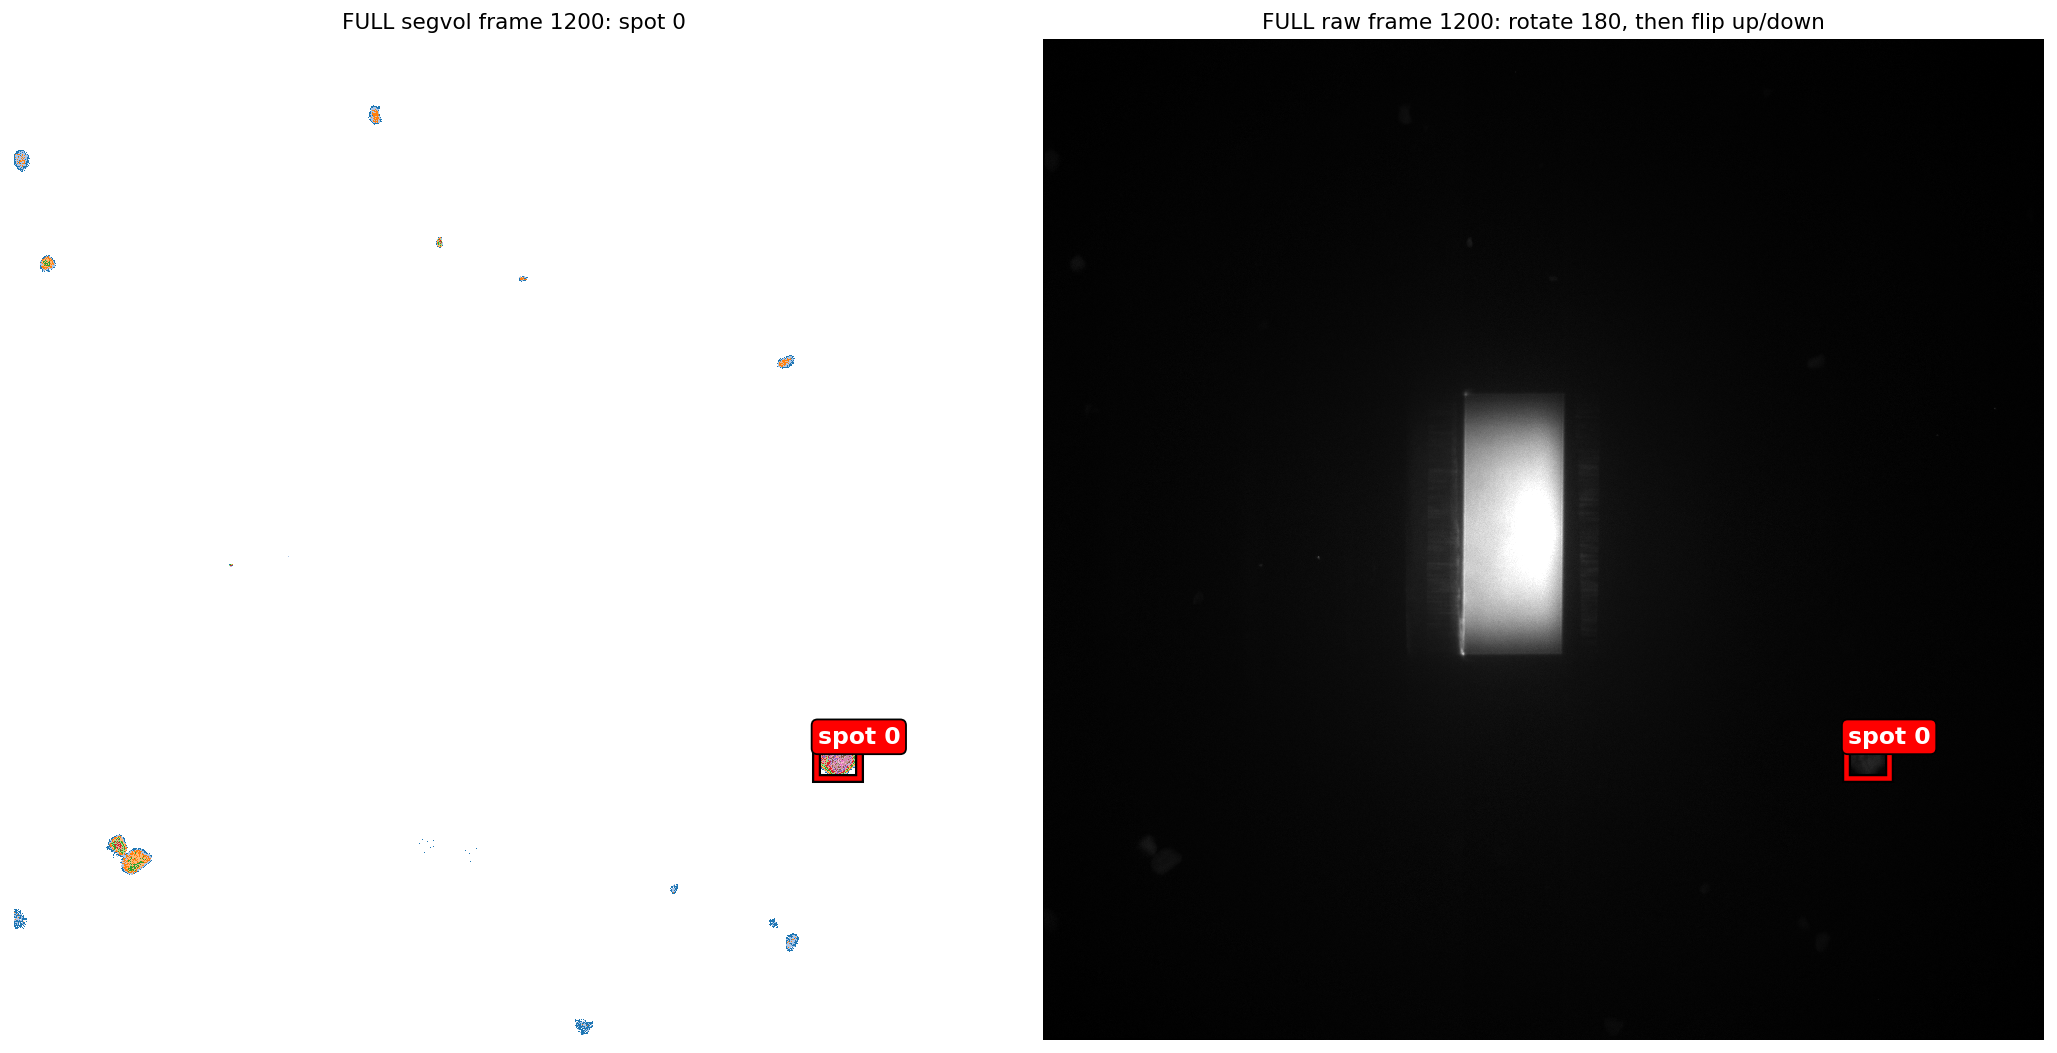

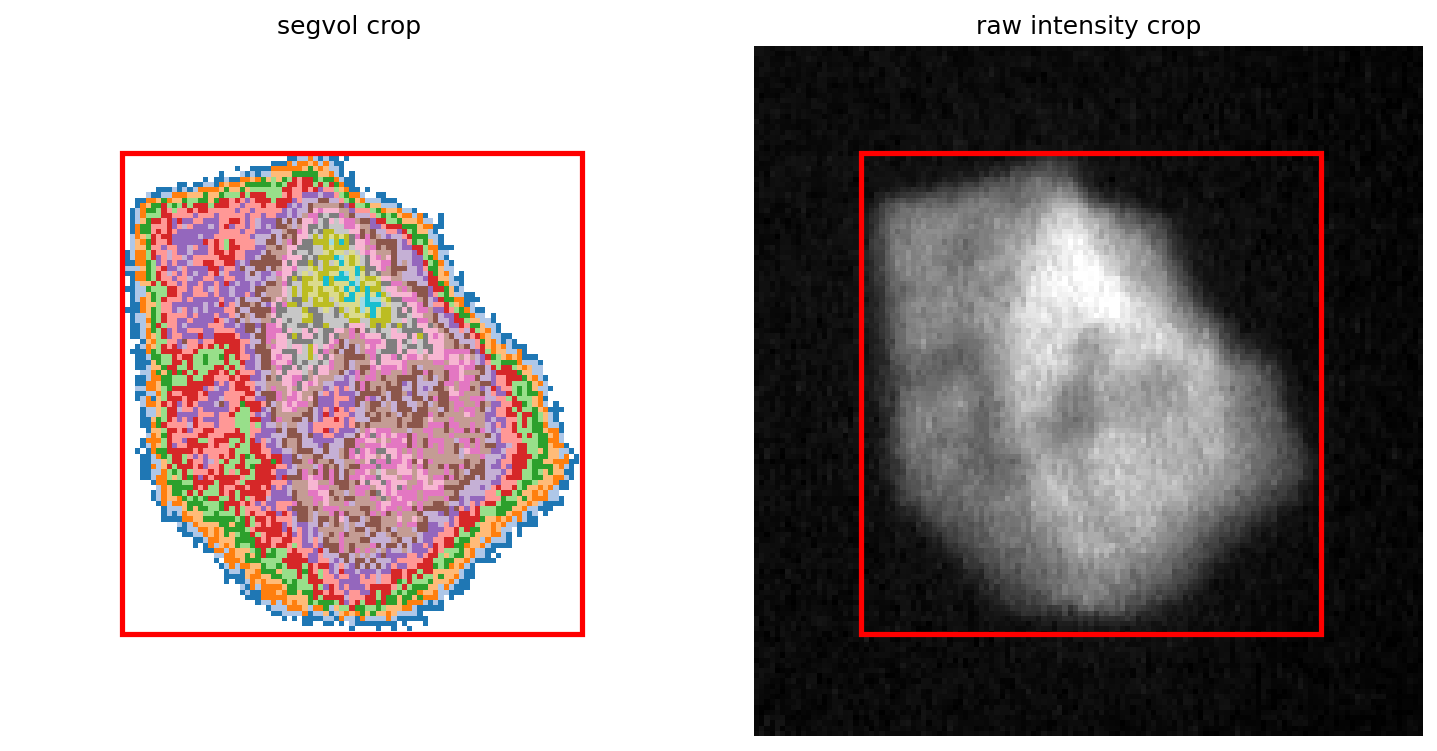

In [ ]:
frame_idx = 1200
spot_id_to_show = 0
pad = 20

seg_path = Path("data/segvol.h5")
raw_path = Path("../data_esrf/Al/_iris_iris_500_cont.h5")
raw_key = "instrument/detector_0/data"

# Optional comparison only. This is preprocessed, not the raw image shown in your screenshot.
full_path = Path("../data_esrf/Al/full.h5")
full_key = "image/data"

def connected_components(mask):
    coords = set(map(tuple, np.argwhere(mask)))
    components = []
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    while coords:
        start = coords.pop()
        queue = deque([start])
        pixels = [start]
        while queue:
            y, x = queue.popleft()
            for dy, dx in neighbors:
                nxt = (y + dy, x + dx)
                if nxt in coords:
                    coords.remove(nxt)
                    queue.append(nxt)
                    pixels.append(nxt)
        components.append(np.array(pixels, dtype=np.int32))
    return sorted(components, key=len, reverse=True)

with h5py.File(seg_path, "r") as f:
    seg_frame = f["segvol"][frame_idx]
    print("segvol:", f["segvol"].shape, f["segvol"].dtype)

components = connected_components(seg_frame > 0)
pixels = components[spot_id_to_show]
y = pixels[:, 0]
x = pixels[:, 1]
y0, y1 = int(y.min()), int(y.max() + 1)
x0, x1 = int(x.min()), int(x.max() + 1)

yy0 = max(0, y0 - pad)
yy1 = min(seg_frame.shape[0], y1 + pad)
xx0 = max(0, x0 - pad)
xx1 = min(seg_frame.shape[1], x1 + pad)

with h5py.File(raw_path, "r") as f:
    raw = f[raw_key]
    print("raw:", raw.shape, raw.dtype)
    raw_frame_original = raw[frame_idx]

# Orient the raw detector image to match segvol visually:
# rotate 180 degrees, then flip up/down.
raw_frame = np.fliplr(np.rot90(raw_frame_original, 3))

print(f"frame {frame_idx}, spot {spot_id_to_show}")
print(f"bbox: y={y0}:{y1}, x={x0}:{x1}, size={y1-y0}x{x1-x0}")
print("raw crop intensity range:", int(raw_frame[yy0:yy1, xx0:xx1].min()), int(raw_frame[yy0:yy1, xx0:xx1].max()))

# Display the full frame with the bbox overlaid.
# The bbox may look small because the image is 2048 x 2048 pixels.
seg_display = np.ma.masked_where(seg_frame == 0, seg_frame)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=130)
axes[0].imshow(seg_display, cmap="tab20", interpolation="nearest")
axes[0].set_title(f"FULL segvol frame {frame_idx}: spot {spot_id_to_show}")

# Raw images are usually dominated by the central beam/reflector, so percentile scaling helps spots appear.
raw_vmin, raw_vmax = np.percentile(raw_frame, [0.5, 99.7])
axes[1].imshow(raw_frame, cmap="gray", vmin=raw_vmin, vmax=raw_vmax, interpolation="nearest")
axes[1].set_title(f"FULL raw frame {frame_idx}: rotate 180, then flip up/down")

for ax in axes:
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="black", linewidth=5, zorder=10))
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5, zorder=11))
    ax.text(
        x0 + 4, y0 + 22, f"spot {spot_id_to_show}",
        color="white", fontsize=13, fontweight="bold", zorder=12,
        bbox={"facecolor": "red", "edgecolor": "black", "boxstyle": "round,pad=0.25"},
    )
    # Full-frame view for orientation: show all 2048 x 2048 pixels.
    ax.set_xlim(0, seg_frame.shape[1])
    ax.set_ylim(seg_frame.shape[0], 0)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Zoomed crop from the rotated/flipped raw frame. This is the most reliable way to check
# whether the selected segvol spot corresponds to visible raw intensity.
seg_crop = np.ma.masked_where(seg_frame[yy0:yy1, xx0:xx1] == 0, seg_frame[yy0:yy1, xx0:xx1])
raw_crop = raw_frame[yy0:yy1, xx0:xx1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
axes[0].imshow(seg_crop, cmap="tab20", interpolation="nearest")
axes[0].set_title("segvol crop")

crop_vmin, crop_vmax = np.percentile(raw_crop, [1, 99.8])
axes[1].imshow(raw_crop, cmap="gray", vmin=crop_vmin, vmax=crop_vmax, interpolation="nearest")
axes[1].set_title("raw intensity crop")

for ax in axes:
    ax.add_patch(Rectangle((x0 - xx0, y0 - yy0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Optional: compare against full.h5 to see how different the preprocessed stack is.
SHOW_FULL_COMPARISON = False
if SHOW_FULL_COMPARISON:
    with h5py.File(full_path, "r") as f:
        full = f[full_key]
        print("full/preprocessed:", full.shape, full.dtype)
        full_frame = np.flipud(np.rot90(full[frame_idx], 2))
    plt.figure(figsize=(6, 6), dpi=130)
    plt.imshow(full_frame, cmap="gray", vmin=np.percentile(full_frame, 1), vmax=np.percentile(full_frame, 99.8))
    plt.gca().add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5))
    plt.title("optional full.h5 comparison, same orientation transform")
    plt.axis("off")
    plt.show()
